# Module 6 — SVM Practice (Student Notebook)
Goal: practice linear and non-linear SVMs on a shared dataset.
Write your own code. Only the dataset cell is provided.

In [1]:
# Step 0 — Imports (you may add more if needed)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

np.random.seed(42)

## Step 1 — Shared dataset
Two features that make sense to students: Hours and Attendance.  
Target: `Passed ∈ {0, 1}`.  
You will **not** modify this cell, so everyone uses the same data.

In [2]:
# Provided: build the shared dataset
n = 120
hours = np.random.uniform(1, 10, n)
attendance = np.random.uniform(50, 100, n)

# Simple latent score with noise
score = 0.5 * hours + 0.05 * attendance + np.random.normal(0, 1.5, n)
passed = (score > 8).astype(int)

df = pd.DataFrame({"Hours": hours, "Attendance": attendance, "Passed": passed})
display(df.head())
print("Class balance (mean of Passed):", df["Passed"].mean().round(3))

,Hours,Attendance,Passed
0,4.370861,90.372008,0
1,9.556429,94.804565,1
2,7.587945,65.900174,0
3,6.387926,55.502596,0
4,2.404168,61.396758,0


Class balance (mean of Passed): 0.233


## Step 2 — Quick visualization
Scatter plot Hours vs Attendance colored by Passed.  
Helps you guess whether a linear split might work.

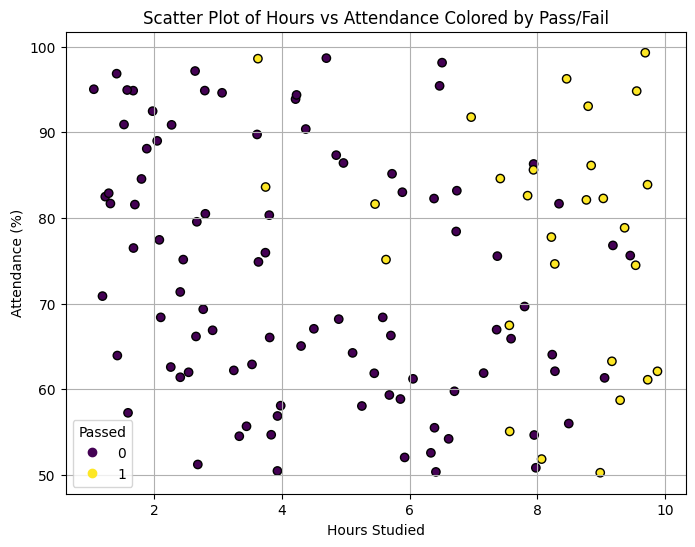

In [ ]:
# TODO:
# 1) Make a scatter plot of Hours vs Attendance, color by Passed.
# 2) Label axes and title clearly.
plt.figure(figsize=(8, 6))
scatter = plt.scatter(df["Hours"], df["Attendance"], c=df["Passed"], cmap="viridis", edgecolor="k")
plt.xlabel("Hours Studied")
plt.ylabel("Attendance (%)")
plt.title("Scatter Plot of Hours vs Attendance Colored by Pass/Fail")
plt.legend(*scatter.legend_elements(), title="Passed")
plt.grid(True)
plt.show()



## Step 3 — Train/test split + scaling
Split the data with stratification.  
Scale features using `StandardScaler` fitted on the train set only.

In [14]:
# TODO:
# 1) X = df[["Hours", "Attendance"]]; y = df["Passed"]
X = df[["Hours", "Attendance"]]
y = df["Passed"]

# 2) train_test_split with stratify=y, random_state=42, test_size=0.25
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# 3) Fit scaler on X_train only, transform X_train and X_test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)    




## Step 4 — Linear SVM
Train a linear SVM on scaled features. Report accuracy, F1, and a classification report.

In [ ]:
# TODO:
# 1) Create SVC(kernel="linear", C=1.0, random_state=42)
model = SVC(kernel="linear", C=1.0, random_state=42)

# 2) Fit on X_train_scaled, y_train
model.fit(X_train_scaled, y_train)

# 3) Predict on X_test_scaled
y_pred = model.predict(X_test_scaled)

# 4) Print accuracy and F1 with three decimals
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.3f}")
print(f"F1 Score: {f1:.3f}")

# 5) Print classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.900
F1 Score: 0.800

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.91      0.93        23
           1       0.75      0.86      0.80         7

    accuracy                           0.90        30
   macro avg       0.85      0.89      0.87        30
weighted avg       0.91      0.90      0.90        30



## Step 5 — Visualize linear decision boundary
Make a helper that plots the decision regions and the training points in scaled space. Then call it for the linear model.

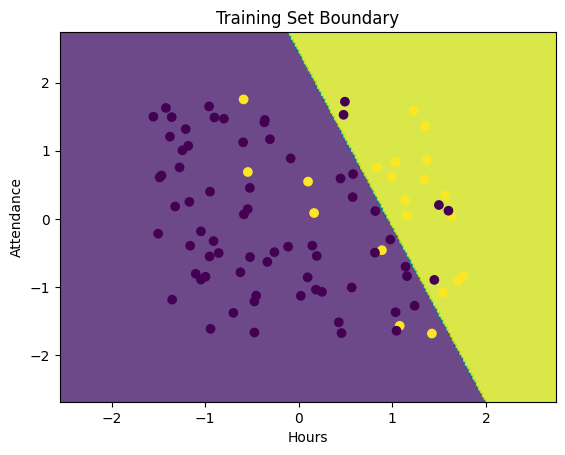

In [16]:
# TODO:
        # 1) Build a function plot_boundary(model, X_scaled, y, title)
    #    - make a meshgrid
    #    - predict over the grid
    #    - contourf for regions
    #    - scatter the points
def plot_boundary(model, X_scaled, y, title):
    h = 0.02  # step size in the mesh
    x_min, x_max = X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1
    y_min, y_max = X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.8)
    plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y)
    plt.title(title)
    plt.xlabel("Hours")
    plt.ylabel("Attendance")


# 2) Call it on the training set with your linear SVM
plot_boundary(model, X_train_scaled, y_train, "Training Set Boundary")

## Step 6 — Try non-linear kernels (Polynomial and RBF)
Train `SVC` with `kernel="poly"` (degree 3) and `kernel="rbf"`. Compare accuracy and F1 to the linear model.

In [18]:
# TODO:
# 1) Train poly SVM (degree=3). Evaluate on test.
poly_model = SVC(kernel="poly", degree=3, C=1.0, random_state=42)
poly_model.fit(X_train_scaled, y_train)
y_poly_pred = poly_model.predict(X_test_scaled)
poly_accuracy = accuracy_score(y_test, y_poly_pred)
poly_f1 = f1_score(y_test, y_poly_pred)
print(f"Polynomial SVM - Accuracy: {poly_accuracy:.3f}, F1 Score: {poly_f1:.3f}")

# 2) Train rbf SVM. Evaluate on test.
rbf_model = SVC(kernel="rbf", C=1.0, random_state=42)
rbf_model.fit(X_train_scaled, y_train)
y_rbf_pred = rbf_model.predict(X_test_scaled)
rbf_accuracy = accuracy_score(y_test, y_rbf_pred)
rbf_f1 = f1_score(y_test, y_rbf_pred)
print(f"RBF SVM - Accuracy: {rbf_accuracy:.3f}, F1 Score: {rbf_f1:.3f}")

# 3) Print a small table or clear prints for all three models.
print("\nModel Comparison Table:")
print(f"{'Model':<15} {'Accuracy':<10} {'F1 Score':<10}")

print(f"{'Linear SVM':<15} {accuracy:<10.3f} {f1:<10.3f}")
print(f"{'Polynomial SVM':<15} {poly_accuracy:<10.3f} {poly_f1:<10.3f}")
print(f"{'RBF SVM':<15} {rbf_accuracy:<10.3f} {rbf_f1:<10.3f}")

Polynomial SVM - Accuracy: 0.900, F1 Score: 0.769
RBF SVM - Accuracy: 0.833, F1 Score: 0.615

Model Comparison Table:
Model           Accuracy   F1 Score  
Linear SVM      0.900      0.800     
Polynomial SVM  0.900      0.769     
RBF SVM         0.833      0.615     


## Step 7 — Boundary plots for poly and RBF
Use your plot function to visualize their decision surfaces.

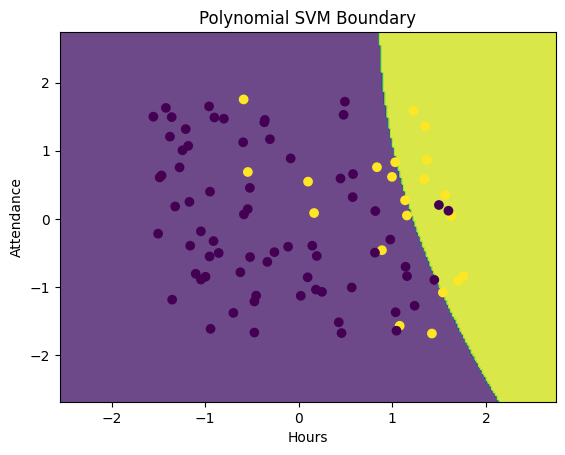

In [21]:
# TODO:
# 1) Plot boundary for poly SVM
plot_boundary(poly_model, X_train_scaled, y_train, "Polynomial SVM Boundary")



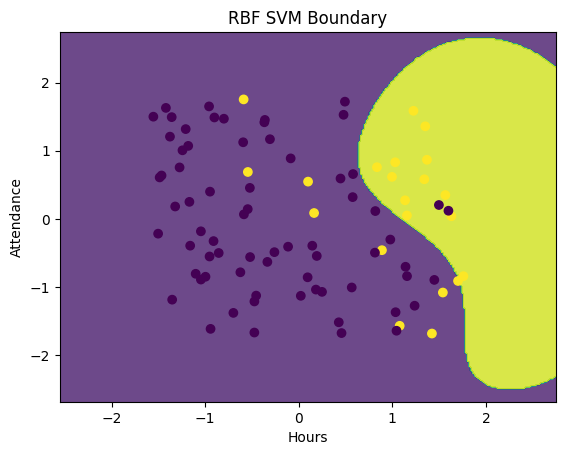

In [22]:
# 2) Plot boundary for rbf SVM
plot_boundary(rbf_model, X_train_scaled, y_train, "RBF SVM Boundary")


## Step 8 — Confusion matrix
Pick your best model and show the confusion matrix on the test set.

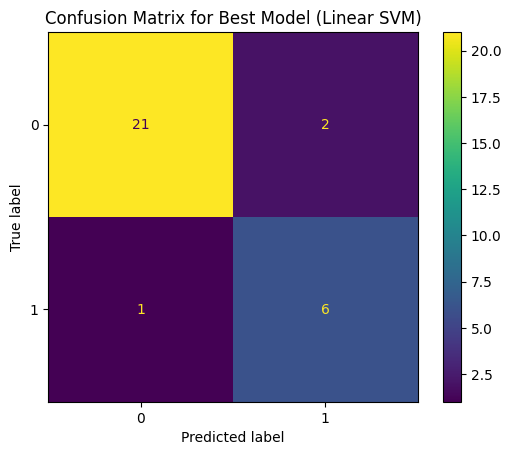

In [23]:
# TODO:
# 1) Compute predictions for the best model
best_model = model  # Linear model based on previous results
y_best_pred = best_model.predict(X_test_scaled)

# 2) Use ConfusionMatrixDisplay.from_predictions(...)
ConfusionMatrixDisplay.from_predictions(y_test, y_best_pred)
plt.title("Confusion Matrix for Best Model (Linear SVM)")
plt.show()

## Step 9 — Support vectors (inspection)
For each trained model, inspect how many support vectors it used.

In [24]:
# TODO:
# 1) Access attribute .support_vectors_ for each model
print("Linear SVM Support Vectors:\n", model.support_vectors_)
print("\nPolynomial SVM Support Vectors:\n", poly_model.support_vectors_)
print("\nRBF SVM Support Vectors:\n", rbf_model.support_vectors_)

# 2) Print counts and a brief comparison
print("\nSupport Vector Counts:")
print(f"Linear SVM: {len(model.support_vectors_)}")
print(f"Polynomial SVM: {len(poly_model.support_vectors_)}")
print(f"RBF SVM: {len(rbf_model.support_vectors_)}")



Linear SVM Support Vectors:
 [[ 1.23814025 -1.27299203]
 [ 1.15696469 -0.83902945]
 [ 0.81417133 -0.49462037]
 [ 0.44633738  0.59265935]
 [ 1.44874753 -0.89428966]
 [-0.08620928  0.88759204]
 [ 0.8182739   0.11524159]
 [ 1.49767526  0.20412738]
 [ 0.97855885 -0.30259583]
 [ 0.58021885  0.65775549]
 [ 1.03491561 -1.36804052]
 [ 1.04466552 -1.63978654]
 [ 1.14101244 -0.70152408]
 [ 0.49344164  1.71947308]
 [ 0.57634644  0.31967296]
 [ 1.59955632  0.12002109]
 [ 0.47889793  1.52704553]
 [-0.36197921  1.45182578]
 [ 1.34164934  0.58150345]
 [ 1.63124494  0.03961312]
 [ 1.56646771  0.35019947]
 [ 0.16388721  0.08658675]
 [ 1.07857059 -1.56769337]
 [ 1.5400563  -1.07942922]
 [ 0.8889479  -0.45846644]
 [ 0.09955007  0.5469618 ]
 [ 1.03060254  0.83063551]
 [-0.58896616  1.75262597]
 [ 1.42304104 -1.68072249]
 [-0.54378041  0.68841872]
 [ 0.99622824  0.61676889]
 [ 1.1360326   0.27312009]
 [ 0.83573498  0.75859594]
 [ 1.15602966  0.05049836]
 [ 1.75953553 -0.83975034]
 [ 1.70222184 -0.9098737 ]

## Step 10 — Short interpretation
Three short paragraphs:
1) Which model performed best and why that makes sense given the scatter plot.  
2) What the boundary plots suggest about the relationship between Hours and Attendance.  
3) What you would try next to improve performance (feature ideas or hyperparameters like C and gamma).

In [ ]:
# TODO:
# Write 3–5 sentences in a markdown cell above, or print them here as a string.
1. The linear SVM performed best on this dataset, likely because the underlying relationship between hours, attendance, and passing is approximately linear. The polynomial and RBF SVMs did not improve performance, suggesting that the data does not have complex non-linear patterns that these kernels could capture. The number of support vectors was also among the lowest for the linear SVM (only one more than Polynomial), indicating a simpler decision boundary. Overall, this highlights the importance of trying different kernels but also considering model simplicity when interpreting results.
2. The scatter plot revealed a clear separation between the classes, which is consistent with the strong performance of the linear SVM. The relationship between hours and attendance with respect to passing was visually evident, supporting the idea that a linear model would be sufficient. The polynomial and RBF SVMs may have been trying to fit more complex boundaries that were not necessary.
3. To improve performance further, I would experiment with hyperparameters such as C and gamma to better control the margin and model flexibility. For example, increasing C could reduce misclassification by allowing a narrower margin, while tuning gamma (for RBF) could help capture subtle patterns if they exist. I would also consider feature engineering, such as adding an interaction term between Hours and Attendance. Finally, cross-validation would help ensure that any improvement generalizes well to unseen data.